## Stock Market Trend Analysis

### Week 2. Model Development & Evaluation

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Features Selection & Data Preparation

In [7]:
df = pd.read_csv("stock_prices_with_indicators.csv")

In [8]:
df.head(2)

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110,160.110,...,2.88,2.880,962644.0,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235,161.235,...,5.39,4.135,1137664.5,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways


In [9]:
df.shape

(15502, 31)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15502 entries, 0 to 15501
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticker            15502 non-null  object 
 1   date              15502 non-null  object 
 2   open              15502 non-null  float64
 3   high              15502 non-null  float64
 4   low               15502 non-null  float64
 5   close             15502 non-null  float64
 6   volume            15502 non-null  float64
 7   adjusted_close    15502 non-null  float64
 8   sma_20            15192 non-null  float64
 9   sma_50            15502 non-null  float64
 10  sma_200           15502 non-null  float64
 11  ema_12            15502 non-null  float64
 12  ema_26            15502 non-null  float64
 13  macd              15191 non-null  float64
 14  macd_signal       15502 non-null  float64
 15  macd_histogram    15502 non-null  float64
 16  rsi_14            15172 non-null  float6

In [11]:
df.describe()

,open,high,low,close,volume,adjusted_close,sma_20,sma_50,sma_200,ema_12,...,bb_width,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d
count,15502.000000,15502.000000,15502.000000,15502.000000,1.550200e+04,15502.000000,15192.000000,15502.000000,15502.000000,15502.000000,...,15171.000000,15502.000000,15502.000000,1.550200e+04,15192.000000,15302.000000,15102.000000,15502.000000,15462.000000,15502.000000
mean,102.408860,104.210076,100.685710,102.447796,1.255806e+06,102.447796,102.145547,101.370939,99.078231,102.205225,...,16.282274,3.731157,3.718369,1.245795e+06,1.000063,0.005172,0.010515,0.007683,0.022965,0.002466
std,58.524307,59.610521,57.519995,58.583470,3.880426e+05,58.583470,57.549051,55.626918,49.001519,57.851272,...,13.645730,2.904011,2.330653,5.659106e+04,0.167556,0.075902,0.108675,0.096457,0.007044,0.053491
min,21.060000,22.080000,21.060000,21.440000,8.018930e+05,21.440000,22.808000,23.391200,25.758150,22.611917,...,0.113137,0.270000,0.650000,8.854700e+05,0.608932,-0.283947,-0.417187,-0.376681,0.001749,-0.635318
25%,63.350000,64.432500,62.235000,63.332500,1.069136e+06,63.332500,63.007500,64.068350,66.673452,62.982891,...,7.937950,1.870000,2.158571,1.207038e+06,0.864243,-0.042132,-0.058712,-0.050586,0.017978,-0.030752
50%,88.540000,90.090000,87.155000,88.650000,1.249854e+06,88.650000,88.149250,87.822600,86.859500,88.338272,...,12.344552,2.970000,3.128929,1.243692e+06,1.001132,0.004793,0.009213,0.007012,0.021983,0.002061
75%,131.052500,132.977500,128.850000,130.967500,1.420747e+06,130.967500,130.658125,130.193450,127.921712,130.549266,...,19.921944,4.620000,4.653571,1.282458e+06,1.131701,0.051565,0.078204,0.068663,0.026906,0.035708
max,512.090000,516.020000,497.210000,509.110000,1.399696e+07,509.110000,489.384000,470.320200,383.890800,494.758062,...,124.994567,39.530000,19.738571,1.578011e+06,1.574700,0.370482,0.669193,0.427233,0.065473,0.245885


In [12]:
df.isnull().sum()

ticker                0
date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
adjusted_close        0
sma_20              310
sma_50                0
sma_200               0
ema_12                0
ema_26                0
macd                311
macd_signal           0
macd_histogram        0
rsi_14              330
bb_middle             0
bb_upper             20
bb_lower             20
bb_width            331
true_range            0
atr_14                0
volume_sma_20         0
volume_ratio        310
momentum_10         200
momentum_20         400
price_to_sma_50       0
volatility_20        40
future_return_5d      0
trend_label           0
dtype: int64

In [13]:
# Converting Dates into datetime format

df["date"] = pd.to_datetime(df["date"])

##### Handling missing values

In [15]:
# Filling the missing values by recomputing values

def compute_indicators(df, close_col="close", volume_col="volume"):
    # --- Recomputed Indicators ---
    recomputed = pd.DataFrame(index=df.index)
    
    # SMA (20-day)
    recomputed["sma_20_recomputed"] = df[close_col].rolling(window=20).mean()
    
    # MACD
    ema_12 = df[close_col].ewm(span=12, adjust=False).mean()
    ema_26 = df[close_col].ewm(span=26, adjust=False).mean()
    recomputed["macd_recomputed"] = ema_12 - ema_26
    recomputed["macd_signal_recomputed"] = recomputed["macd_recomputed"].ewm(span=9, adjust=False).mean()
    recomputed["macd_histogram_recomputed"] = recomputed["macd_recomputed"] - recomputed["macd_signal_recomputed"]
    
    # RSI (14-day)
    delta = df[close_col].diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=14).mean()
    avg_loss = pd.Series(loss).rolling(window=14).mean()
    rs = avg_gain / avg_loss
    recomputed["rsi_14_recomputed"] = 100 - (100 / (1 + rs))
    
    # Bollinger Bands (20-day)
    bb_middle = df[close_col].rolling(window=20).mean()
    bb_std = df[close_col].rolling(window=20).std()
    recomputed["bb_upper_recomputed"] = bb_middle + (2 * bb_std)
    recomputed["bb_lower_recomputed"] = bb_middle - (2 * bb_std)
    recomputed["bb_width_recomputed"] = recomputed["bb_upper_recomputed"] - recomputed["bb_lower_recomputed"]
    
    # Volume Ratio
    volume_sma_20 = df[volume_col].rolling(window=20).mean()
    recomputed["volume_ratio_recomputed"] = df[volume_col] / volume_sma_20
    
    # Momentum
    recomputed["momentum_10_recomputed"] = df[close_col].diff(10)
    recomputed["momentum_20_recomputed"] = df[close_col].diff(20)
    
    # Volatility (20-day rolling std of returns)
    returns = df[close_col].pct_change()
    recomputed["volatility_20_recomputed"] = returns.rolling(window=20).std()
    
    # --- Merge with Original Indicators ---
    combined = pd.concat([df, recomputed], axis=1)
    return combined


In [16]:
# df has now original indicators+ recomputed indicators
df_combined = compute_indicators(df)

# Compare original vs recomputed side by side
print(df_combined[[
    "sma_20", "sma_20_recomputed",
    "macd", "macd_recomputed",
    "rsi_14", "rsi_14_recomputed",
    "bb_upper", "bb_upper_recomputed",
    "bb_lower", "bb_lower_recomputed",
    "bb_width", "bb_width_recomputed",
    "volume_ratio", "volume_ratio_recomputed",
    "momentum_10", "momentum_10_recomputed",
    "momentum_20", "momentum_20_recomputed",
    "volatility_20", "volatility_20_recomputed"
]].head(30))


        sma_20  sma_20_recomputed      macd  macd_recomputed      rsi_14  \
0   160.110000                NaN  0.000000         0.000000         NaN   
1   161.235000                NaN  0.179487         0.179487  100.000000   
2   161.416667                NaN  0.271798         0.271798   79.505300   
3   162.830000                NaN  0.763018         0.763018   92.857143   
4   163.400000                NaN  1.028298         1.028298   79.284963   
5   163.555000                NaN  1.116728         1.116728   69.429098   
6   163.805714                NaN  1.251461         1.251461   71.959459   
7   163.303750                NaN  0.902418         0.902418   49.078341   
8   162.572222                NaN  0.373767         0.373767   41.703377   
9   161.720000                NaN -0.257670        -0.257670   36.883117   
10  161.449091                NaN -0.375317        -0.375317   47.535085   
11  161.255833                NaN -0.432103        -0.432103   48.261178   
12  160.9723

In [17]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15502 entries, 0 to 15501
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ticker                     15502 non-null  object        
 1   date                       15502 non-null  datetime64[ns]
 2   open                       15502 non-null  float64       
 3   high                       15502 non-null  float64       
 4   low                        15502 non-null  float64       
 5   close                      15502 non-null  float64       
 6   volume                     15502 non-null  float64       
 7   adjusted_close             15502 non-null  float64       
 8   sma_20                     15192 non-null  float64       
 9   sma_50                     15502 non-null  float64       
 10  sma_200                    15502 non-null  float64       
 11  ema_12                     15502 non-null  float64       
 12  ema_

In [18]:
df_combined.isna().sum()

ticker                         0
date                           0
open                           0
high                           0
low                            0
close                          0
volume                         0
adjusted_close                 0
sma_20                       310
sma_50                         0
sma_200                        0
ema_12                         0
ema_26                         0
macd                         311
macd_signal                    0
macd_histogram                 0
rsi_14                       330
bb_middle                      0
bb_upper                      20
bb_lower                      20
bb_width                     331
true_range                     0
atr_14                         0
volume_sma_20                  0
volume_ratio                 310
momentum_10                  200
momentum_20                  400
price_to_sma_50                0
volatility_20                 40
future_return_5d               0
trend_labe

In [19]:
df_combined.shape

(15502, 43)

In [20]:
# Dropping original indicators(with missing values) to keep recomputed indicators
cols_to_drop = [
    "sma_20", "macd", "macd_signal", "macd_histogram",
    "rsi_14", "bb_upper", "bb_lower", "bb_width",
    "volume_ratio", "momentum_10", "momentum_20", "volatility_20"
]

df_drop_cols = df_combined.drop(columns=cols_to_drop)

print(df_drop_cols.head())


   ticker       date    open    high     low   close     volume  \
0  STK001 2021-01-04  158.09  160.97  158.09  160.11   962644.0   
1  STK001 2021-01-05  163.16  165.50  160.76  162.36  1312685.0   
2  STK001 2021-01-06  161.89  162.51  160.94  161.78  1449177.0   
3  STK001 2021-01-07  163.33  167.90  163.33  167.07  1534833.0   
4  STK001 2021-01-08  168.20  168.20  164.12  165.68   848261.0   

   adjusted_close      sma_50     sma_200  ...  macd_signal_recomputed  \
0          160.11  160.110000  160.110000  ...                0.000000   
1          162.36  161.235000  161.235000  ...                0.035897   
2          161.78  161.416667  161.416667  ...                0.083078   
3          167.07  162.830000  162.830000  ...                0.219066   
4          165.68  163.400000  163.400000  ...                0.380912   

   macd_histogram_recomputed  rsi_14_recomputed  bb_upper_recomputed  \
0                   0.000000                NaN                  NaN   
1       

In [21]:
df_drop_cols.shape

(15502, 31)

In [22]:
df_drop_cols.head(2)

,ticker,date,open,high,low,close,volume,adjusted_close,sma_50,sma_200,...,macd_signal_recomputed,macd_histogram_recomputed,rsi_14_recomputed,bb_upper_recomputed,bb_lower_recomputed,bb_width_recomputed,volume_ratio_recomputed,momentum_10_recomputed,momentum_20_recomputed,volatility_20_recomputed
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110,160.110,...,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235,161.235,...,0.035897,0.14359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df_drop_cols.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
       'adjusted_close', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'bb_middle',
       'true_range', 'atr_14', 'volume_sma_20', 'price_to_sma_50',
       'future_return_5d', 'trend_label', 'sma_20_recomputed',
       'macd_recomputed', 'macd_signal_recomputed',
       'macd_histogram_recomputed', 'rsi_14_recomputed', 'bb_upper_recomputed',
       'bb_lower_recomputed', 'bb_width_recomputed', 'volume_ratio_recomputed',
       'momentum_10_recomputed', 'momentum_20_recomputed',
       'volatility_20_recomputed'],
      dtype='object')

In [24]:
# Renaming recomputed indicators (by removing "_recomputed" suffix)

df_drop_cols = df_drop_cols.rename(
    columns=lambda col: col.replace("_recomputed", "") if "_recomputed" in col else col
)

print(df_drop_cols.head())


   ticker       date    open    high     low   close     volume  \
0  STK001 2021-01-04  158.09  160.97  158.09  160.11   962644.0   
1  STK001 2021-01-05  163.16  165.50  160.76  162.36  1312685.0   
2  STK001 2021-01-06  161.89  162.51  160.94  161.78  1449177.0   
3  STK001 2021-01-07  163.33  167.90  163.33  167.07  1534833.0   
4  STK001 2021-01-08  168.20  168.20  164.12  165.68   848261.0   

   adjusted_close      sma_50     sma_200  ...  macd_signal  macd_histogram  \
0          160.11  160.110000  160.110000  ...     0.000000        0.000000   
1          162.36  161.235000  161.235000  ...     0.035897        0.143590   
2          161.78  161.416667  161.416667  ...     0.083078        0.188720   
3          167.07  162.830000  162.830000  ...     0.219066        0.543952   
4          165.68  163.400000  163.400000  ...     0.380912        0.647386   

   rsi_14  bb_upper  bb_lower  bb_width  volume_ratio  momentum_10  \
0     NaN       NaN       NaN       NaN           Na

In [25]:
df_drop_cols.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
       'adjusted_close', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'bb_middle',
       'true_range', 'atr_14', 'volume_sma_20', 'price_to_sma_50',
       'future_return_5d', 'trend_label', 'sma_20', 'macd', 'macd_signal',
       'macd_histogram', 'rsi_14', 'bb_upper', 'bb_lower', 'bb_width',
       'volume_ratio', 'momentum_10', 'momentum_20', 'volatility_20'],
      dtype='object')

In [26]:
df_drop_cols.shape

(15502, 31)

In [27]:
df_drop_cols["trend_label"].unique()

array(['Uptrend', 'Sideways', 'Downtrend'], dtype=object)

In [28]:
df_drop_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15502 entries, 0 to 15501
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticker            15502 non-null  object        
 1   date              15502 non-null  datetime64[ns]
 2   open              15502 non-null  float64       
 3   high              15502 non-null  float64       
 4   low               15502 non-null  float64       
 5   close             15502 non-null  float64       
 6   volume            15502 non-null  float64       
 7   adjusted_close    15502 non-null  float64       
 8   sma_50            15502 non-null  float64       
 9   sma_200           15502 non-null  float64       
 10  ema_12            15502 non-null  float64       
 11  ema_26            15502 non-null  float64       
 12  bb_middle         15502 non-null  float64       
 13  true_range        15502 non-null  float64       
 14  atr_14            1550

In [29]:
df_drop_cols.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'volume',
       'adjusted_close', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'bb_middle',
       'true_range', 'atr_14', 'volume_sma_20', 'price_to_sma_50',
       'future_return_5d', 'trend_label', 'sma_20', 'macd', 'macd_signal',
       'macd_histogram', 'rsi_14', 'bb_upper', 'bb_lower', 'bb_width',
       'volume_ratio', 'momentum_10', 'momentum_20', 'volatility_20'],
      dtype='object')

In [30]:
# Features selection

cols_irrelevant = [
        'ticker', 'date', 'open', 'high', 'low', 'adjusted_close', 'sma_50', 'ema_26',
        'bb_middle', 'atr_14', 'price_to_sma_50', 'macd_signal', 'macd_histogram',
        'bb_upper', 'bb_lower', 'volume_ratio'
]

df_model = df_drop_cols.drop(columns=cols_irrelevant)

print(df_model.head())

    close     volume     sma_200      ema_12  true_range  volume_sma_20  \
0  160.11   962644.0  160.110000  160.110000        2.88      962644.00   
1  162.36  1312685.0  161.235000  160.456154        5.39     1137664.50   
2  161.78  1449177.0  161.416667  160.659822        1.57     1241502.00   
3  167.07  1534833.0  162.830000  161.646004        6.12     1314834.75   
4  165.68   848261.0  163.400000  162.266618        4.08     1221520.00   

   future_return_5d trend_label  sma_20      macd  rsi_14  bb_width  \
0          0.026357     Uptrend     NaN  0.000000     NaN       NaN   
1          0.018169    Sideways     NaN  0.179487     NaN       NaN   
2         -0.012301    Sideways     NaN  0.271798     NaN       NaN   
3         -0.061950   Downtrend     NaN  0.763018     NaN       NaN   
4         -0.070196   Downtrend     NaN  1.028298     NaN       NaN   

   momentum_10  momentum_20  volatility_20  
0          NaN          NaN            NaN  
1          NaN          NaN     

In [31]:
df_model.shape

(15502, 15)

In [32]:
df_model.columns

Index(['close', 'volume', 'sma_200', 'ema_12', 'true_range', 'volume_sma_20',
       'future_return_5d', 'trend_label', 'sma_20', 'macd', 'rsi_14',
       'bb_width', 'momentum_10', 'momentum_20', 'volatility_20'],
      dtype='object')

In [33]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15502 entries, 0 to 15501
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   close             15502 non-null  float64
 1   volume            15502 non-null  float64
 2   sma_200           15502 non-null  float64
 3   ema_12            15502 non-null  float64
 4   true_range        15502 non-null  float64
 5   volume_sma_20     15502 non-null  float64
 6   future_return_5d  15502 non-null  float64
 7   trend_label       15502 non-null  object 
 8   sma_20            15483 non-null  float64
 9   macd              15502 non-null  float64
 10  rsi_14            15489 non-null  float64
 11  bb_width          15483 non-null  float64
 12  momentum_10       15492 non-null  float64
 13  momentum_20       15482 non-null  float64
 14  volatility_20     15482 non-null  float64
dtypes: float64(14), object(1)
memory usage: 1.8+ MB


In [34]:
df_model.head()

,close,volume,sma_200,ema_12,true_range,volume_sma_20,future_return_5d,trend_label,sma_20,macd,rsi_14,bb_width,momentum_10,momentum_20,volatility_20
0,160.11,962644.0,160.110000,160.110000,2.88,962644.00,0.026357,Uptrend,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
1,162.36,1312685.0,161.235000,160.456154,5.39,1137664.50,0.018169,Sideways,NaN,0.179487,NaN,NaN,NaN,NaN,NaN
2,161.78,1449177.0,161.416667,160.659822,1.57,1241502.00,-0.012301,Sideways,NaN,0.271798,NaN,NaN,NaN,NaN,NaN
3,167.07,1534833.0,162.830000,161.646004,6.12,1314834.75,-0.061950,Downtrend,NaN,0.763018,NaN,NaN,NaN,NaN,NaN
4,165.68,848261.0,163.400000,162.266618,4.08,1221520.00,-0.070196,Downtrend,NaN,1.028298,NaN,NaN,NaN,NaN,NaN


In [35]:
df_model.isna().sum()

close                0
volume               0
sma_200              0
ema_12               0
true_range           0
volume_sma_20        0
future_return_5d     0
trend_label          0
sma_20              19
macd                 0
rsi_14              13
bb_width            19
momentum_10         10
momentum_20         20
volatility_20       20
dtype: int64

In [36]:
#Handling missing values by dropping NaNs

df_model.dropna(inplace=True)

In [37]:
df_model.isnull().sum()

close               0
volume              0
sma_200             0
ema_12              0
true_range          0
volume_sma_20       0
future_return_5d    0
trend_label         0
sma_20              0
macd                0
rsi_14              0
bb_width            0
momentum_10         0
momentum_20         0
volatility_20       0
dtype: int64

In [38]:
df_model.duplicated().sum()

np.int64(0)

In [39]:
# Saving modeling dataset

df_model.to_csv("modeling_dataset.csv", index=False)

### Model Development

In [41]:
# Features separation from the target

features = df_model.drop("trend_label", axis=1)

In [42]:
label = df_model["trend_label"]

In [43]:
features.head(2)

,close,volume,sma_200,ema_12,true_range,volume_sma_20,future_return_5d,sma_20,macd,rsi_14,bb_width,momentum_10,momentum_20,volatility_20
20,152.81,1467983.0,157.712381,154.28686,3.87,1230876.80,-0.022512,157.5925,-2.348076,31.936416,21.594779,-5.93,-7.30,0.017942
21,152.62,1417942.0,157.480909,154.03042,4.24,1236139.65,-0.033482,157.1055,-2.307113,37.751964,21.541158,-6.51,-9.74,0.017535


In [44]:
label.head()

20    Downtrend
21    Downtrend
22     Sideways
23     Sideways
24     Sideways
Name: trend_label, dtype: object

In [45]:
# Class Distribution in Target variable

label.value_counts(normalize=True) * 100

trend_label
Uptrend      35.725358
Downtrend    32.405374
Sideways     31.869268
Name: proportion, dtype: float64

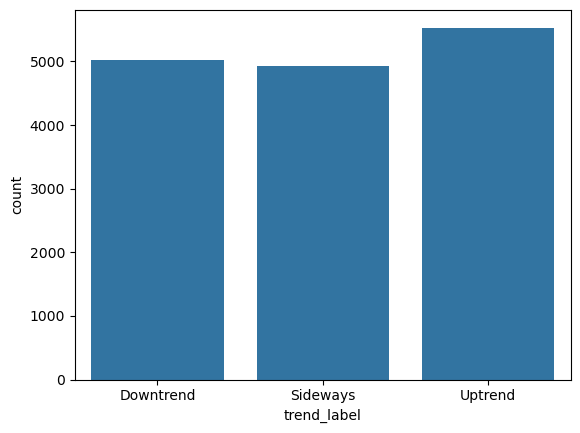

In [46]:
sns.countplot(x=df_model["trend_label"]);

##### Assessing features distribution

In [48]:
len(features.columns)

14

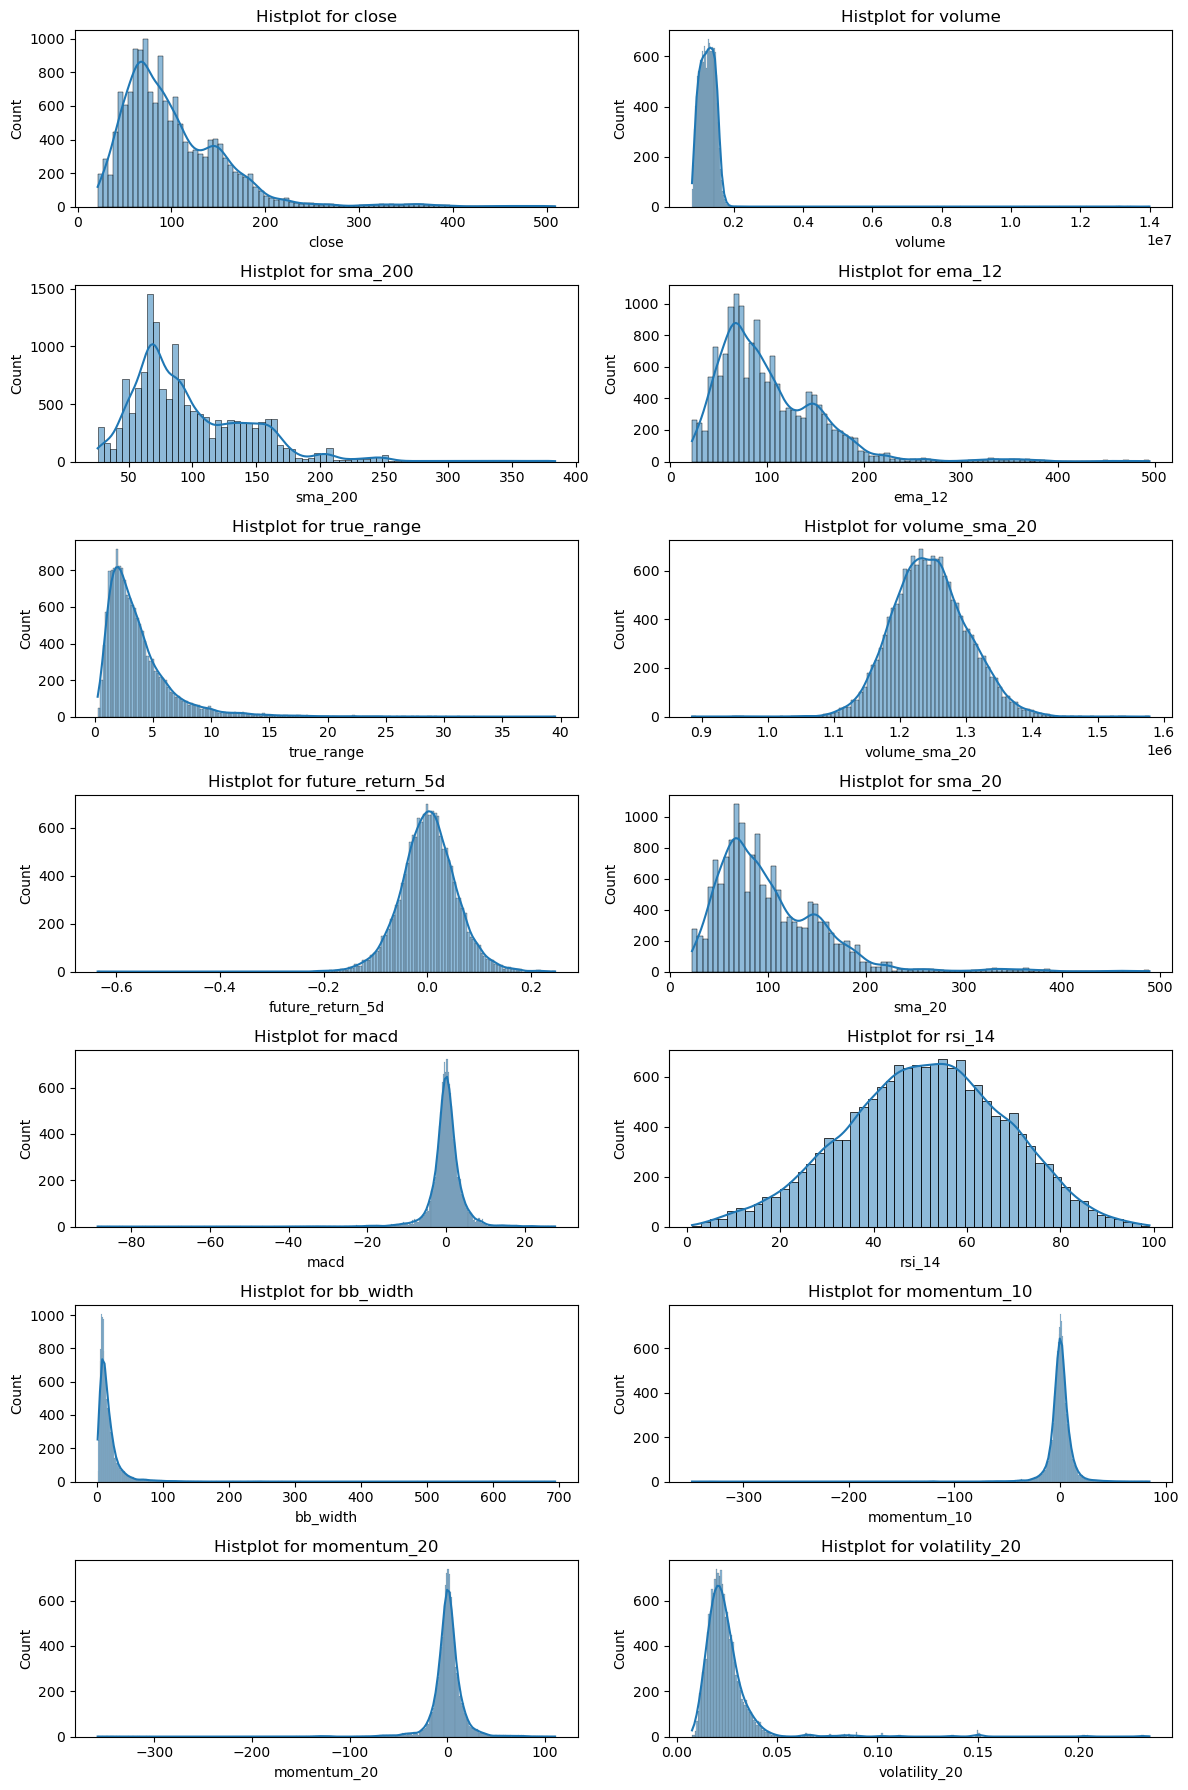

In [49]:
fig, ax = plt.subplots(nrows=7, ncols=2, figsize=(12,18))
ax=ax.flatten()
for idx, col in enumerate(features):
    sns.histplot(df_model[col], ax=ax[idx], kde=True)
    ax[idx].set_title(f"Histplot for {col}")
plt.tight_layout()
plt.show()

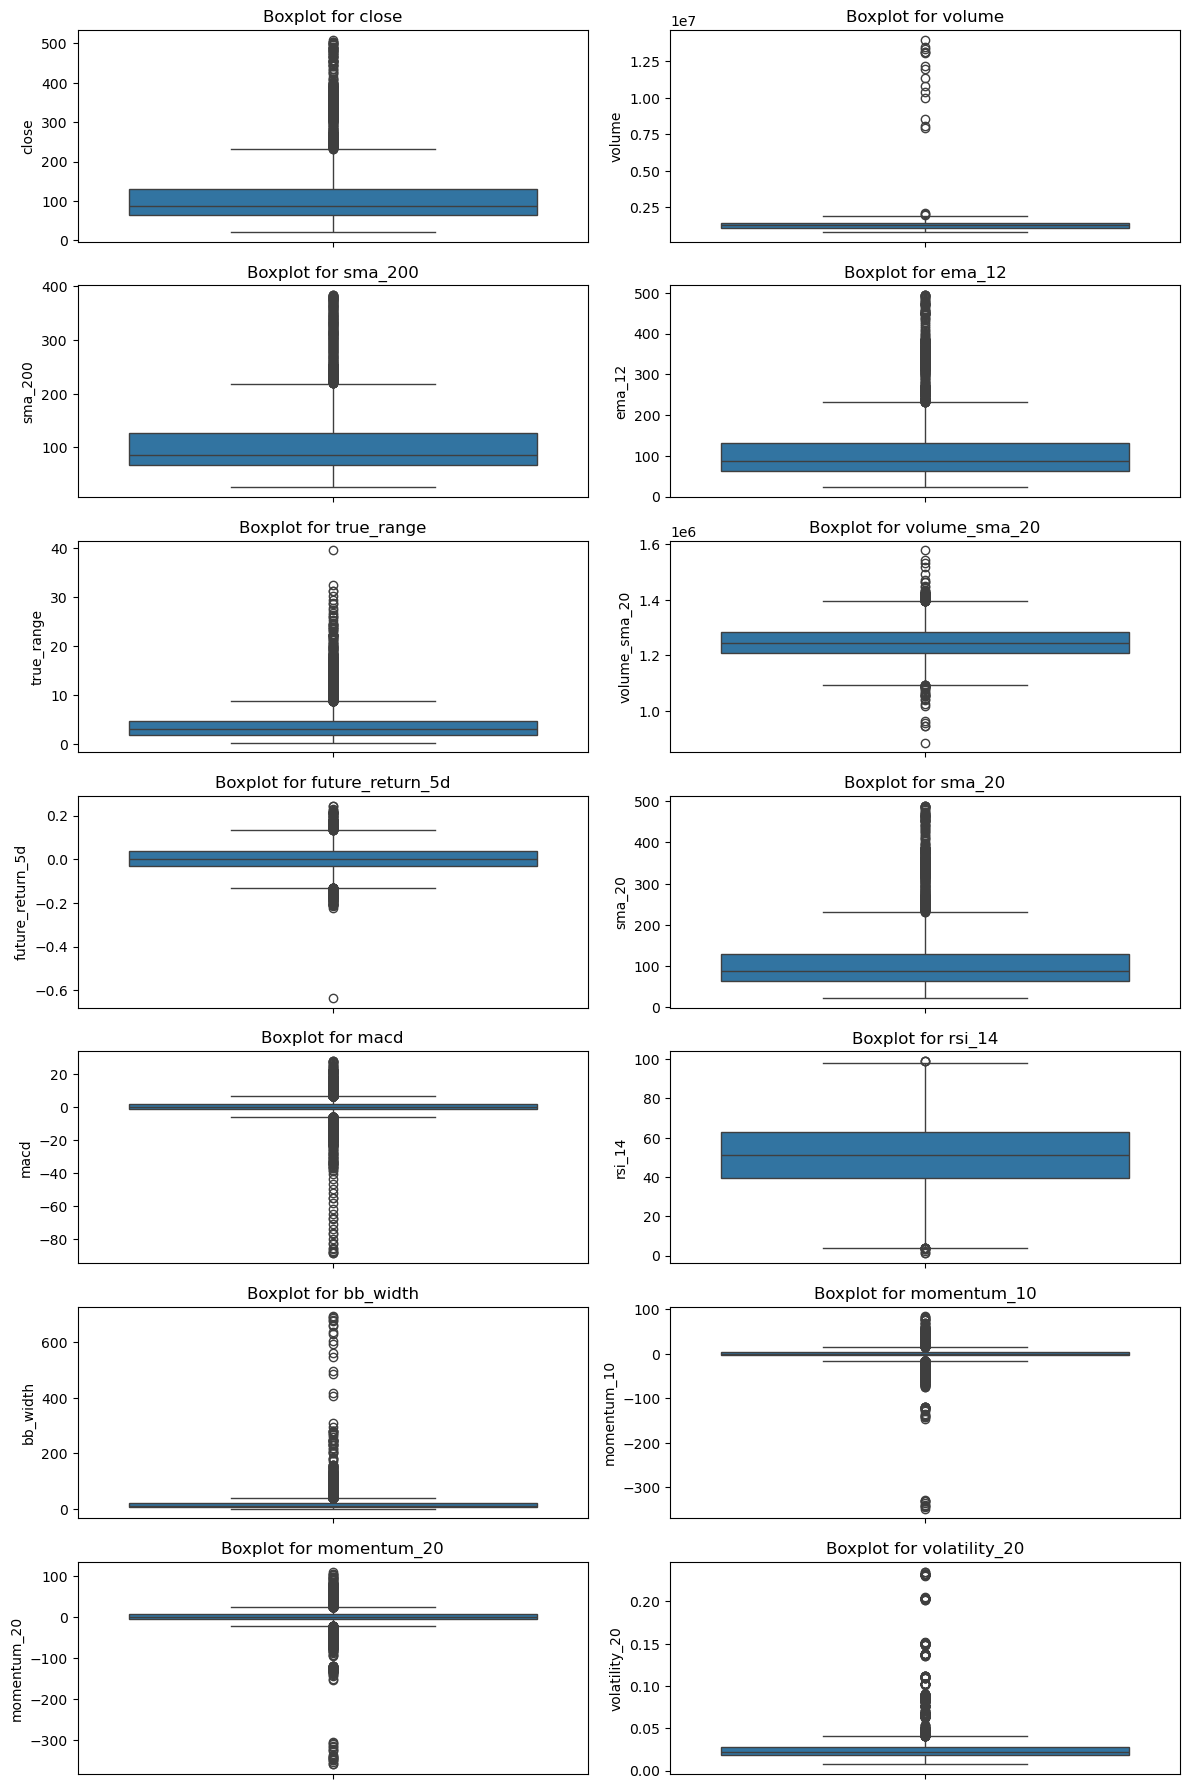

In [50]:
# Assessing outliers

fig, ax = plt.subplots(nrows=7, ncols=2, figsize=(12,18))
ax=ax.flatten()
for idx, col in enumerate(features):
    sns.boxplot(df_model[col], ax=ax[idx])
    ax[idx].set_title(f"Boxplot for {col}")
plt.tight_layout()
plt.show()

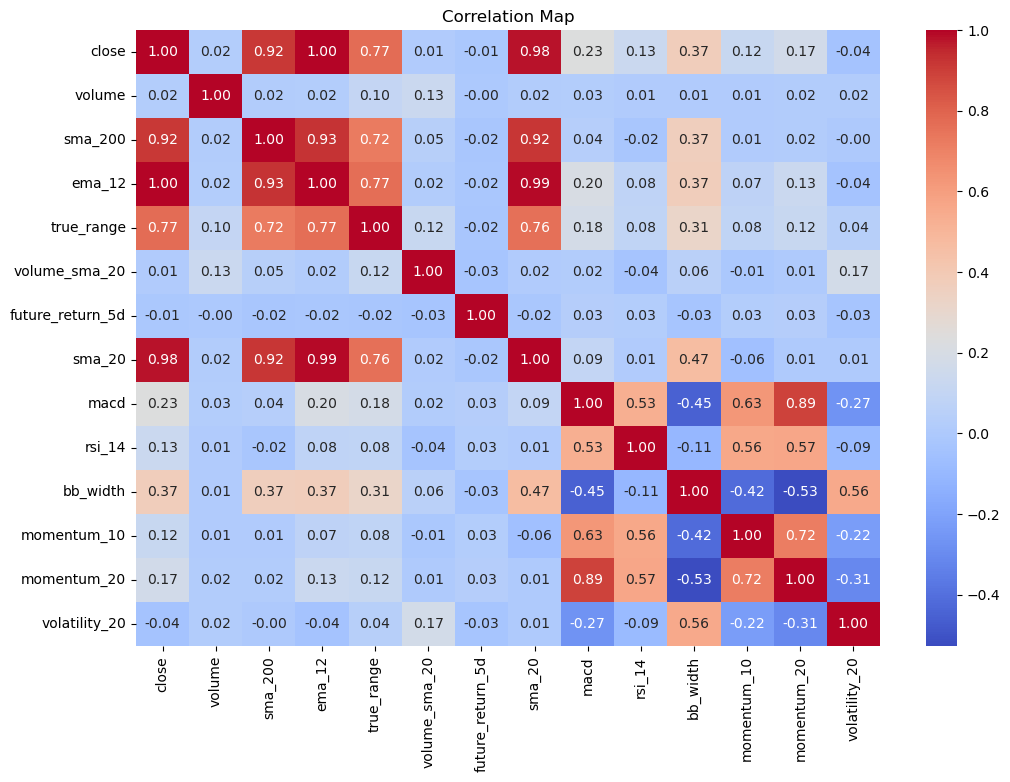

In [51]:
# Correlation map

correlation_map = features.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation_map, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Correlation Map")

plt.show()

### Data Splitting

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
Xtrain, Xtest, ytrain, ytest = train_test_split(features, label, test_size=0.3, random_state=42)

In [55]:
print(f"Training data size {len(Xtrain)}")
print(f"Testing data size {len(Xtest)}")

Training data size 10837
Testing data size 4645


In [56]:
ytrain.value_counts(normalize=True)*100

trend_label
Uptrend      35.388023
Downtrend    32.499769
Sideways     32.112208
Name: proportion, dtype: float64

### Model Training & Evaluation

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

C:\Users\gluzi\anaconda3\envs\StockMarketProject\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistics Regression Classification
              precision    recall  f1-score   support

   Downtrend    0.35185   0.15251   0.21279      1495
    Sideways    0.43182   0.07840   0.13271      1454
     Uptrend    0.37128   0.81722   0.51059      1696

    accuracy                        0.37201      4645
   macro avg    0.38498   0.34938   0.28536      4645
weighted avg    0.38398   0.37201   0.29646      4645



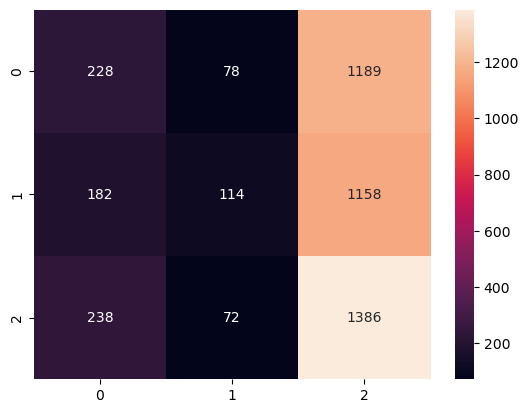

In [59]:
# Model initialization
model = LogisticRegression(random_state=42, max_iter=1000)

# Model fitting
model.fit(Xtrain, ytrain)

# Predictions
predictions = model.predict(Xtest)

# Evaluation
report = classification_report(ytest, predictions, digits=5)
matrix = confusion_matrix(ytest, predictions)

print("Logistics Regression Classification")
print(report)

# Confusion Matrix Heatmap
sns.heatmap(matrix, annot=True, fmt="g")
plt.show()


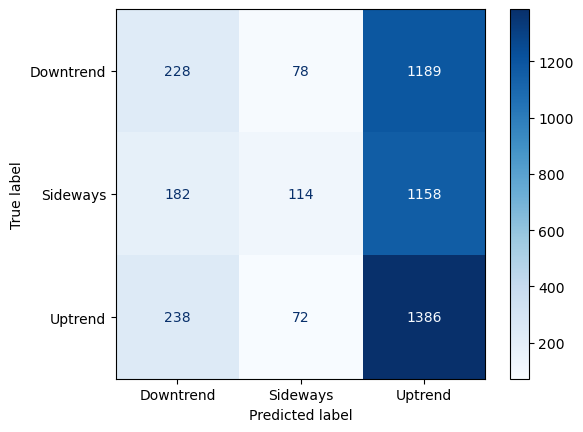

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
predictions = model.predict(Xtest)

# Confusion matrix with labels
matrix = confusion_matrix(ytest, predictions, labels=model.classes_)

# Display with class names
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.show()


In [61]:
predictions[:10]

array(['Uptrend', 'Uptrend', 'Uptrend', 'Uptrend', 'Uptrend', 'Sideways',
       'Uptrend', 'Uptrend', 'Uptrend', 'Uptrend'], dtype=object)

In [62]:
ytest.values[:10]

array(['Downtrend', 'Sideways', 'Downtrend', 'Downtrend', 'Downtrend',
       'Sideways', 'Uptrend', 'Uptrend', 'Uptrend', 'Uptrend'],
      dtype=object)

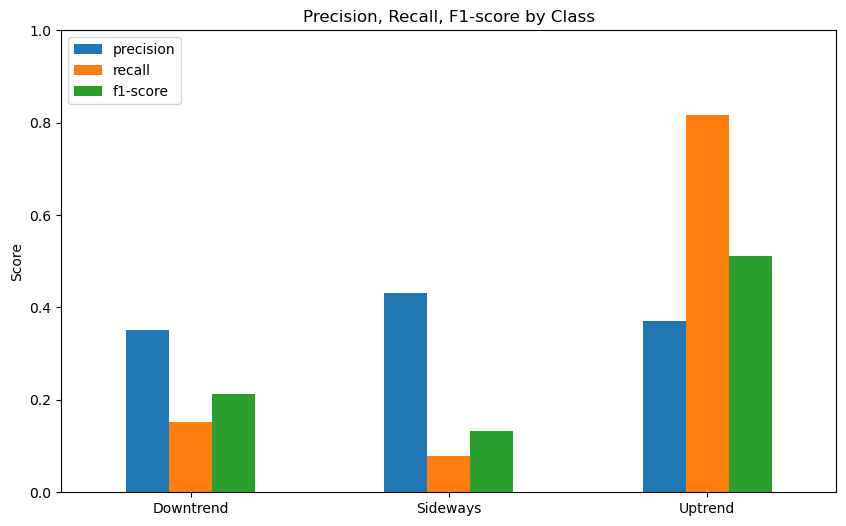

In [63]:
# Bar Chart of selected metrics by class

# Evaluation
report_dict = classification_report(ytest, predictions, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Keep only classes (exclude 'accuracy', 'macro avg', 'weighted avg')
class_metrics = report_df.iloc[:-3][["precision", "recall", "f1-score"]]

# Plot bar chart
class_metrics.plot(kind="bar", figsize=(10,6))
plt.title("Precision, Recall, F1-score by Class")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="upper left")
plt.show()
